In [88]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

# Degree Distribution

In [89]:
import numpy as np

real_degrees_larvae = np.load("analysis-original/larvae_deg.npy")
null1 = np.load("analysis/larvae_null0_degseq.npy")
null2 = np.load("analysis/larvae_null1_degseq.npy")
null3 = np.load("analysis/larvae_null2_degseq.npy")


In [90]:
import matplotlib.pyplot as plt

def draw_degree_distribution(degrees, n_buckets=10, show=True):
    kmin = max(min(degrees), 1)
    kmax = max(degrees)

    if show:
        print(f"Min degree: {kmin}, Max degree: {kmax}")

    linear_edges = np.linspace(kmin, kmax, num=n_buckets+1)
    linear_midpoints = (linear_edges[:-1] + linear_edges[1:]) / 2
    linear_density, _ = np.histogram(degrees, linear_edges, density=True)

    log_edges = np.logspace(np.log10(kmin), np.log10(kmax), num=n_buckets+1)
    log_midpoints = 10 ** ((np.log10(log_edges)[:-1] + np.log10(log_edges)[1:]) / 2)
    log_density, _ = np.histogram(degrees, log_edges, density=True)

    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.suptitle("(a) The degree distibution")
    fig.subplots_adjust(wspace=0.2, hspace=1)

    ax[0].plot(linear_midpoints, linear_density, marker='o', linestyle='none')
    ax[0].set_xlabel(r"degree $k$", fontsize=16)
    ax[0].set_ylabel(r"$P(k)$", fontsize=16)

    ax[1].loglog(log_midpoints, log_density, marker='o', linestyle='none')
    ax[1].set_xlabel(r"degree $k$", fontsize=16)
    ax[1].set_ylabel(r"$P(k)$", fontsize=16)

    if show:
        plt.show()

    return fig, ax

Min degree: 1, Max degree: 329


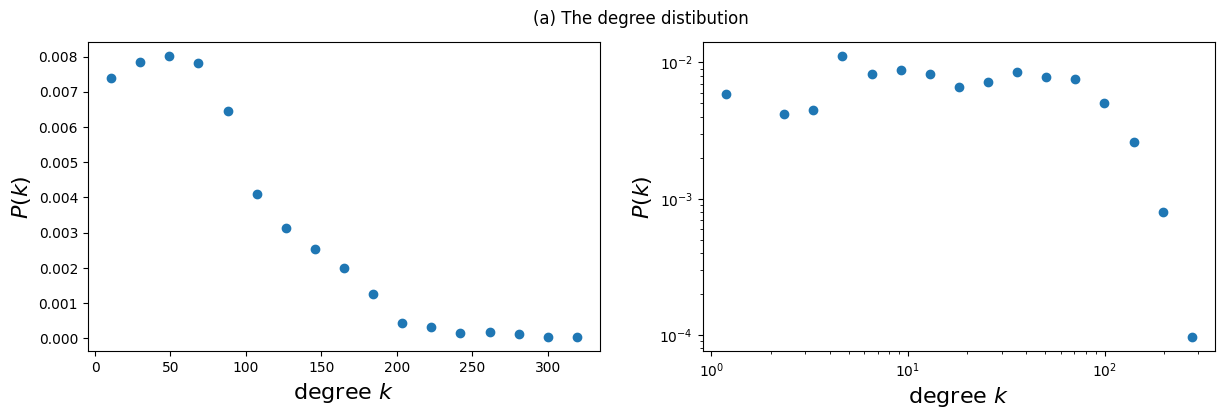

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='degree $k$', ylabel='$P(k)$'>,
        <Axes: xlabel='degree $k$', ylabel='$P(k)$'>], dtype=object))

In [91]:
draw_degree_distribution(list(real_degrees_larvae[0]), 17)

In [92]:
real_degrees_adult = np.load("analysis-original/adult_deg.npy")[0]

Min degree: 1, Max degree: 12784


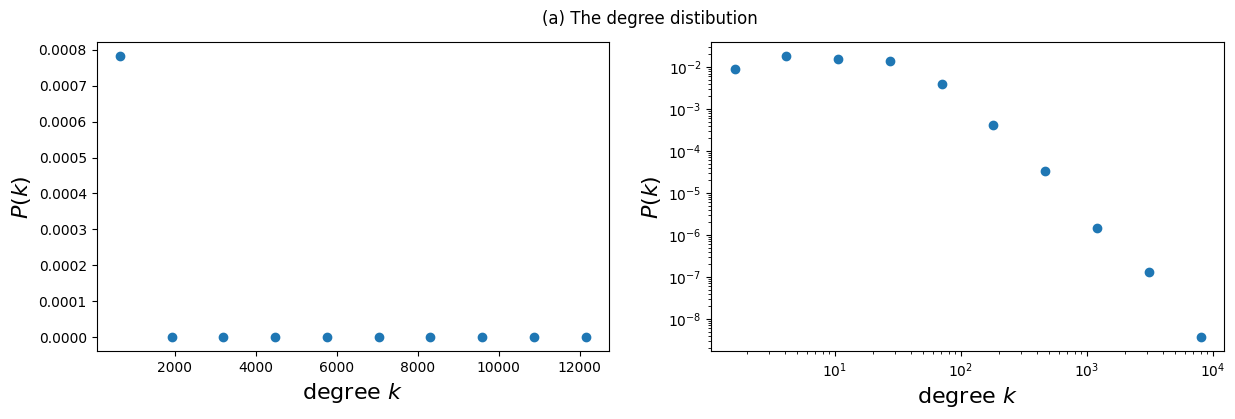

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='degree $k$', ylabel='$P(k)$'>,
        <Axes: xlabel='degree $k$', ylabel='$P(k)$'>], dtype=object))

In [93]:
draw_degree_distribution(real_degrees_adult)

# Segregation

In [94]:
import pandas as pd


In [95]:
df_orig = pd.read_csv('analysis-original/larvae_metrics.csv')
df_orig

,Network,Nodes,Edges,Clustering,Global_Eff,Local_Eff,Avg_Path_Len
0,larvae_ws,2952,110140,0.178132,0.32739,0.404485,inf


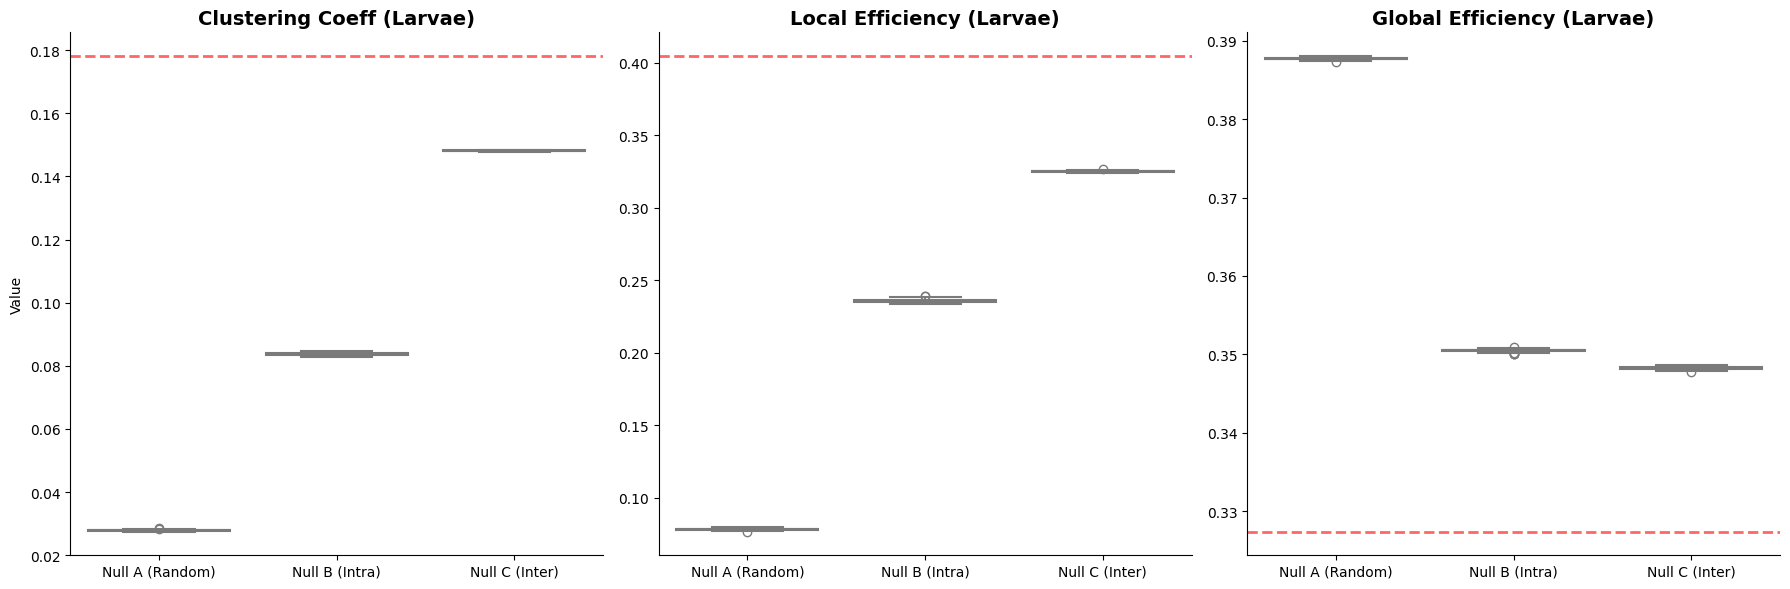

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
# import pandas as pd
import numpy as np

df = pd.read_csv('analysis/results_metrics_larvae.csv')
df_orig = pd.read_csv('analysis-original/larvae_metrics.csv')

REAL_LARVAE_VALUES = {
    'Clustering':   df_orig.iloc[0, 3],  
    'Local_Eff':    df_orig.iloc[0, 5],  
    'Global_Eff':   df_orig.iloc[0, 4]   
}
df['Null_ID'] = df['Network'].apply(lambda x: x.split('_')[1])

null_map = {
    'null0': 'Null A (Random)',
    'null1': 'Null B (Intra)',
    'null2': 'Null C (Inter)'
}
df['Null_Type'] = df['Null_ID'].map(null_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('Clustering', 'Clustering Coeff (Larvae)'), 
    ('Local_Eff', 'Local Efficiency (Larvae)'), 
    ('Global_Eff', 'Global Efficiency (Larvae)')
]

colors = {"Null A (Random)": "#d3d3d3", "Null B (Intra)": "#a1c9f4", "Null C (Inter)": "#ff9f9b"}
order = ['Null A (Random)', 'Null B (Intra)', 'Null C (Inter)']

for i, (col_name, title) in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(x='Null_Type', y=col_name, data=df, 
                ax=ax, order=order, palette=colors, linewidth=1.5)
    
    real_val = REAL_LARVAE_VALUES[col_name]
    
    ax.axhline(real_val, color='red', linestyle='--', linewidth=2, alpha=0.6, label='Real Larva')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i==0 else "")
    
    sns.despine(ax=ax)
    
plt.tight_layout()
plt.show()

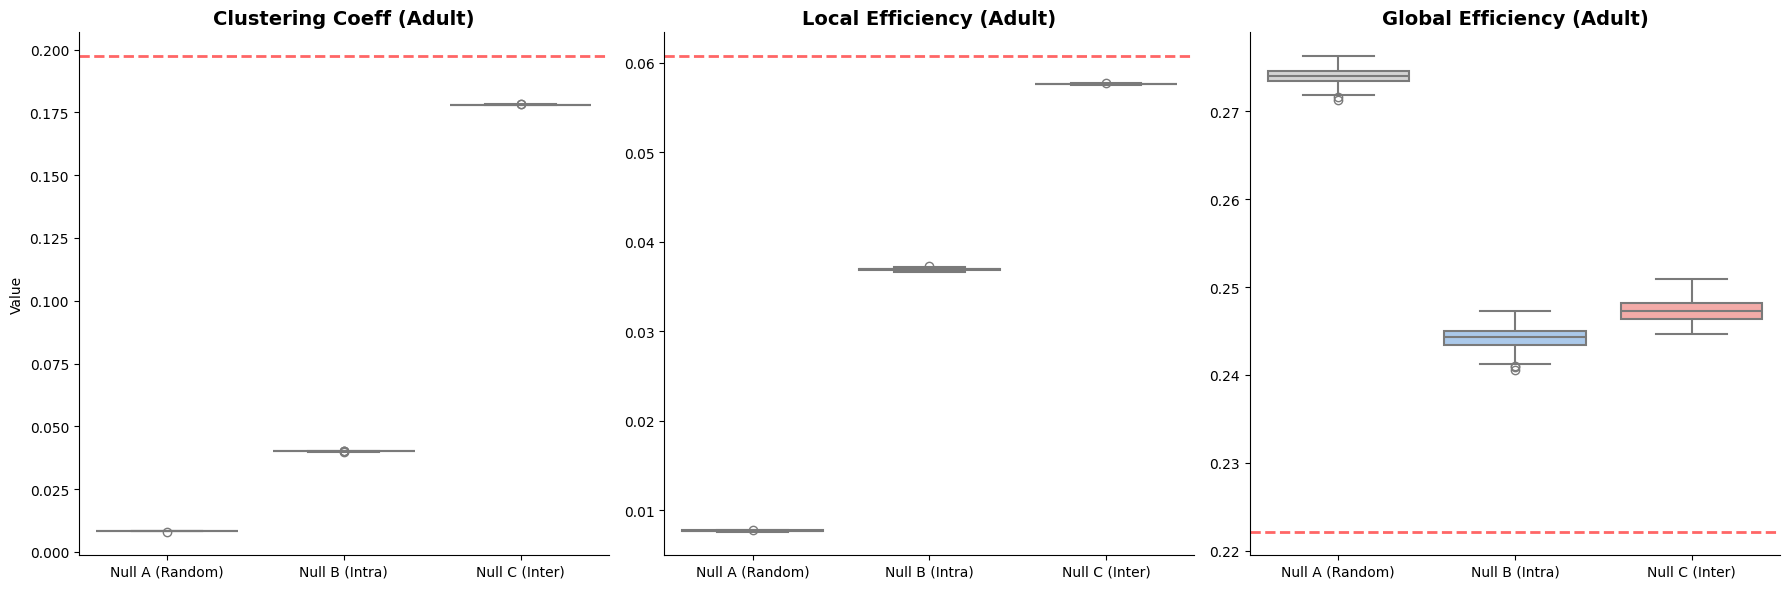

In [97]:
df = pd.read_csv('analysis/results_metrics_adult.csv')
df_orig = pd.read_csv('analysis-original/adult_metrics.csv')

REAL_LARVAE_VALUES = {
    'Clustering':   df_orig.iloc[0, 3],  
    'Local_Eff':    df_orig.iloc[0, 5],  
    'Global_Eff':   df_orig.iloc[0, 4]   
}

df['Null_ID'] = df['Network'].apply(lambda x: x.split('_')[1])
null_map = {
    'null0': 'Null A (Random)',
    'null1': 'Null B (Intra)',
    'null2': 'Null C (Inter)'
}
df['Null_Type'] = df['Null_ID'].map(null_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('Clustering', 'Clustering Coeff (Adult)'), 
    ('Local_Eff', 'Local Efficiency (Adult)'), 
    ('Global_Eff', 'Global Efficiency (Adult)')
]

colors = {"Null A (Random)": "#d3d3d3", "Null B (Intra)": "#a1c9f4", "Null C (Inter)": "#ff9f9b"}
order = ['Null A (Random)', 'Null B (Intra)', 'Null C (Inter)']

for i, (col_name, title) in enumerate(metrics):
    ax = axes[i]
    
    sns.boxplot(x='Null_Type', y=col_name, data=df, 
                ax=ax, order=order, palette=colors, linewidth=1.5)
    
    real_val = REAL_LARVAE_VALUES[col_name]
    
    ax.axhline(real_val, color='red', linestyle='--', linewidth=2, alpha=0.6, label='Real Larva')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Value" if i==0 else "")
    
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [98]:
def load_and_prep(file_path_nulls, file_path_real, dataset_name):
    df = pd.read_csv(file_path_nulls)
    df['Null_ID'] = df['Network'].apply(lambda x: x.split('_')[1])
    df['Null_Type'] = df['Null_ID'].map(null_map)
    
    df_real = pd.read_csv(file_path_real)
    
    real_values = {
        'Clustering': df_real.iloc[0, 3],  
        'Local_Eff':  df_real.iloc[0, 5],  
        'Global_Eff': df_real.iloc[0, 4]   
    }
    
    return df, real_values

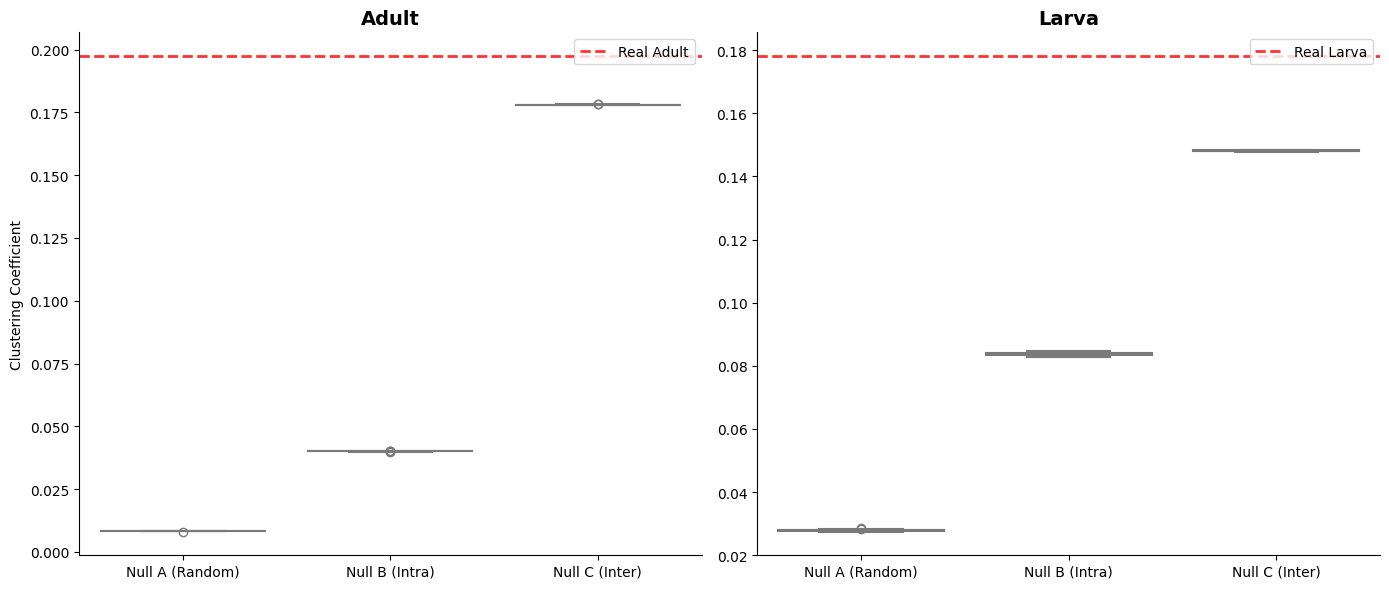

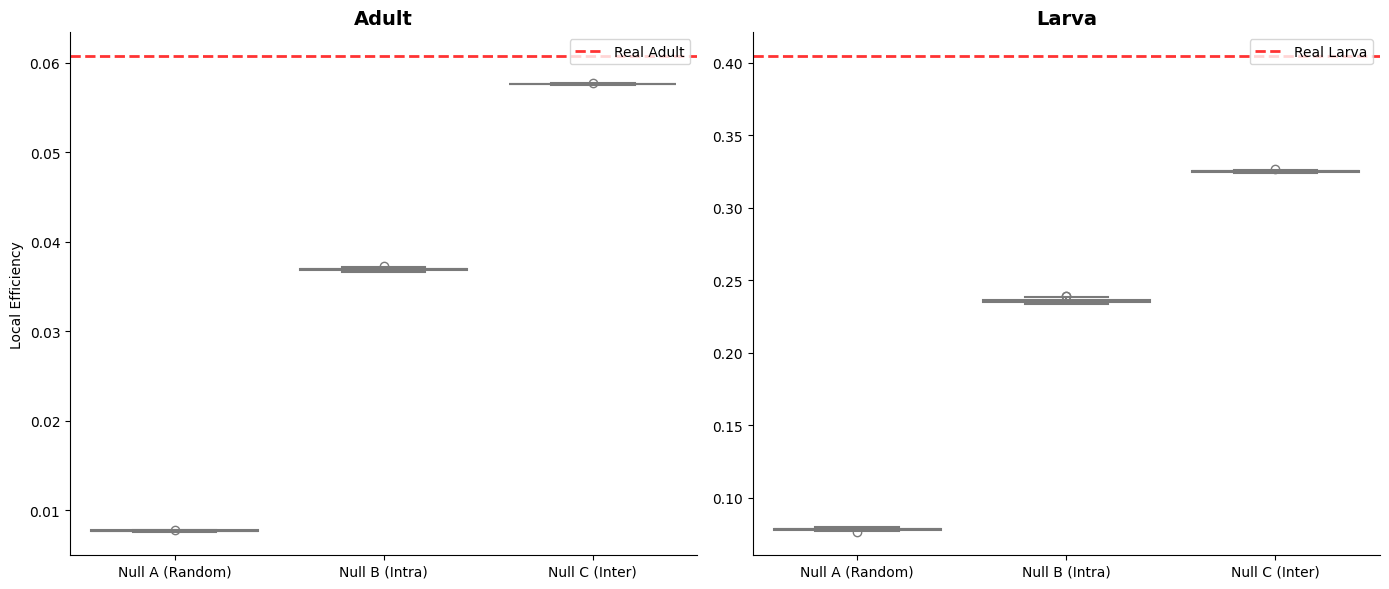

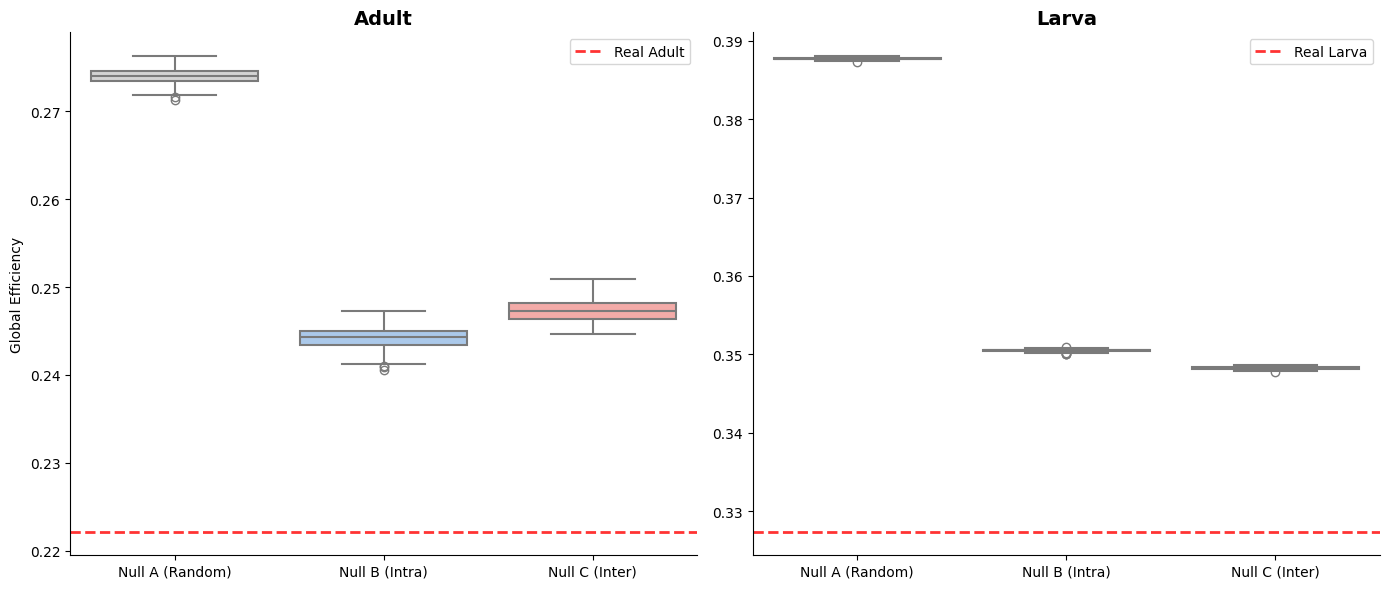

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics = [
    ('Clustering', 'Clustering Coefficient'), 
    ('Local_Eff', 'Local Efficiency'), 
    ('Global_Eff', 'Global Efficiency')
]
null_map = {
    'null0': 'Null A (Random)',
    'null1': 'Null B (Intra)',
    'null2': 'Null C (Inter)'
}

colors = {
    "Null A (Random)": "#d3d3d3", 
    "Null B (Intra)": "#a1c9f4", 
    "Null C (Inter)": "#ff9f9b"
}
order = ['Null A (Random)', 'Null B (Intra)', 'Null C (Inter)']

df_adult, real_adult = load_and_prep('analysis/results_metrics_adult.csv', 'analysis-original/adult_metrics.csv', 'Adult')
df_larva, real_larva = load_and_prep('analysis/results_metrics_larvae.csv', 'analysis-original/larvae_metrics.csv', 'Larva')

for metric_col, metric_title in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
    
    datasets = [
        ('Adult', df_adult, real_adult, axes[0]),
        ('Larva', df_larva, real_larva, axes[1])
    ]
    
    for name, df_data, real_vals, ax in datasets:
        
        sns.boxplot(x='Null_Type', y=metric_col, data=df_data, 
                    ax=ax, order=order, palette=colors, linewidth=1.5)
        
        real_val = real_vals[metric_col]
        ax.axhline(real_val, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'Real {name}')
        
        ax.set_title(f"{name}", fontsize=14, fontweight='bold')
        ax.set_ylabel(metric_title if name == 'Adult' else "") 
        ax.set_xlabel("")
        
        ax.legend(loc='upper right')        
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

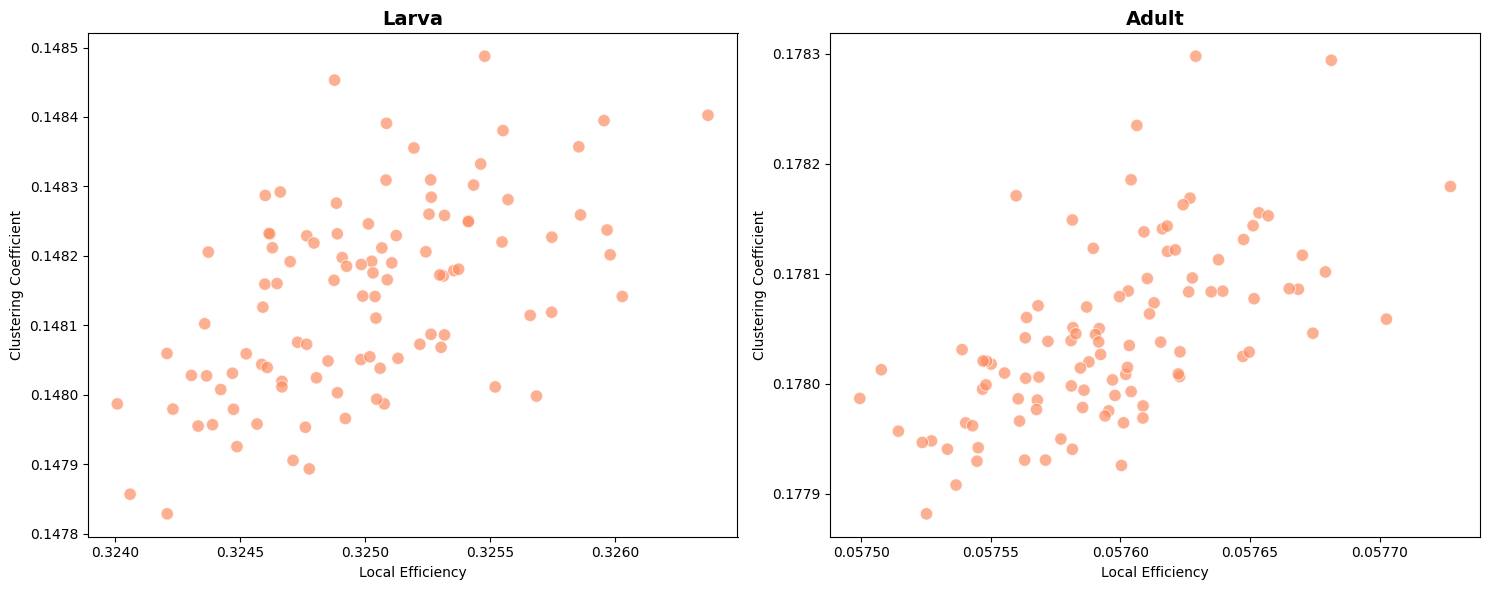

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df1 = pd.read_csv('analysis/results_metrics_adult.csv')
df2 = pd.read_csv('analysis/results_metrics_larvae.csv')

df1['Stage'] = 'Adult'
df2['Stage'] = 'Larva'

df = pd.concat([df1, df2], axis=0)

df['Null_ID'] = df['Network'].apply(lambda x: x.split('_')[1])
df = df[df['Null_ID'] == 'null2']
null_map = {
    'null0': 'Null A (Random)',
    'null1': 'Null B (Intra)',
    'null2': 'Null C (Inter)'
}
df['Null_Type'] = df['Null_ID'].map(null_map)

larvae_df = df[df['Stage'] == 'Larva']
adult_df  = df[df['Stage'] == 'Adult']

real_larva = {'x': 0.40, 'y': 0.18} # x=Local_Eff, y=Clustering
real_adult = {'x': 0.06, 'y': 0.20} 

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = {
    'Null A (Random)': '#999999',
    'Null B (Intra)': '#66c2a5',
    'Null C (Inter)': '#fc8d62' 
}

sns.scatterplot(
    data=larvae_df, x='Local_Eff', y='Clustering', hue='Null_Type', 
    palette=palette, ax=axes[0], s=80, alpha=0.7, edgecolor='white', legend=False
)

axes[0].set_title("Larva", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Local Efficiency")
axes[0].set_ylabel("Clustering Coefficient")

sns.scatterplot(
    data=adult_df, x='Local_Eff', y='Clustering', hue='Null_Type', 
    palette=palette, ax=axes[1], s=80, alpha=0.7, edgecolor='white', legend=False
)

axes[1].set_title("Adult", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Local Efficiency")
axes[1].set_ylabel("Clustering Coefficient")

plt.tight_layout()
plt.show()

# Centrality

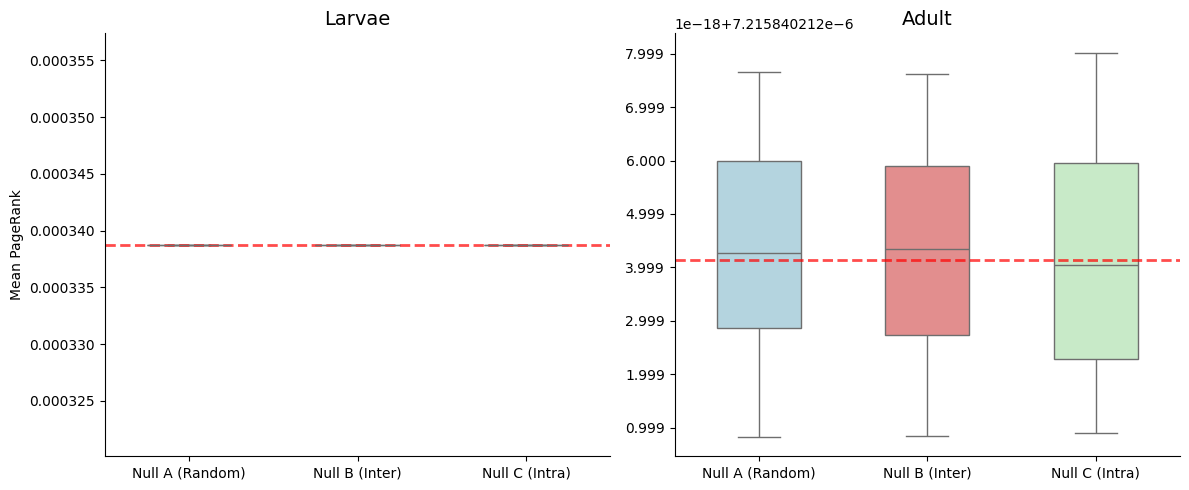

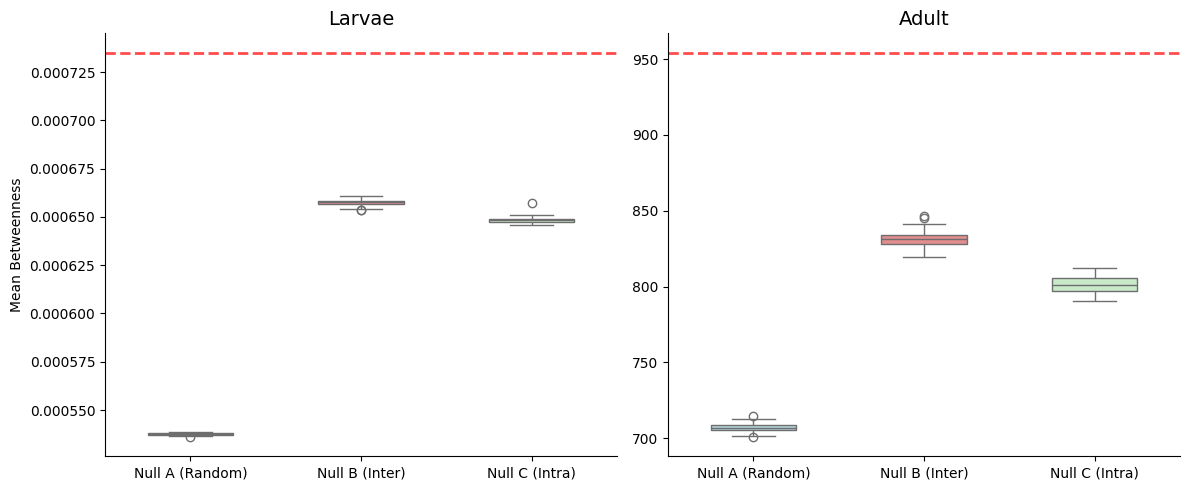

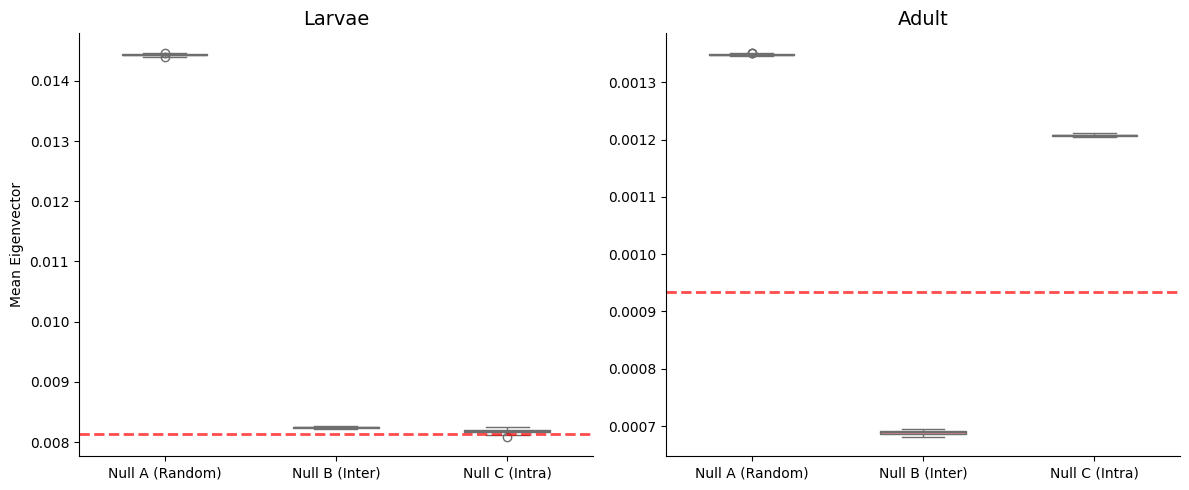

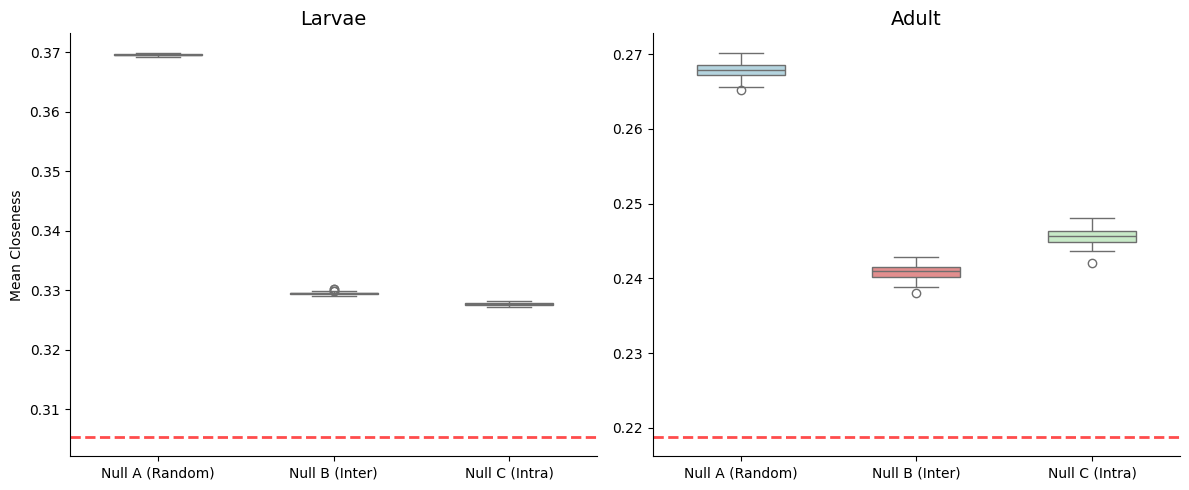

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df1 = pd.read_csv('analysis/results_centrality_adult.csv')
df2 = pd.read_csv('analysis/results_centrality_larvae.csv')

df1['Stage'] = 'Adult'
df2['Stage'] = 'Larva'

df = pd.concat([df1, df2], axis=0)

df_real_adult = pd.read_csv('analysis-original/adult_centrality.csv')
df_real_larvae = pd.read_csv('analysis-original/larvae_centrality.csv')

REAL_VALS = {
    'PageRank_Mean':    {'Larvae': df_real_larvae.loc[0, 'PageRank_Mean'], 'Adult': df_real_adult.loc[0, 'PageRank_Mean']}, 
    'Betweenness_Mean': {'Larvae': df_real_larvae.loc[0, 'Betweenness_Mean'], 'Adult': df_real_adult.loc[0, 'Betweenness_Mean']}, 
    'Eigenvector_Mean': {'Larvae': df_real_larvae.loc[0, 'Eigenvector_Mean'], 'Adult': df_real_adult.loc[0, 'Eigenvector_Mean']}, 
    'Closeness_Mean':  {'Larvae': df_real_larvae.loc[0, 'Closeness_Mean'], 'Adult': df_real_adult.loc[0, 'Closeness_Mean']}  
}


df['Stage'] = df['Network'].apply(lambda x: x.split('_')[0].capitalize())
df['Null_ID'] = df['Network'].apply(lambda x: x.split('_')[1])
null_map = {
    'null0': 'Null A (Random)', 
    'null1': 'Null B (Inter)',  
    'null2': 'Null C (Intra)',  
}
df['Null_Type'] = df['Null_ID'].map(null_map)


metrics = [
    ('PageRank_Mean',    'PageRank Centrality (Mean)',    'Mean PageRank'),
    ('Betweenness_Mean', 'Betweenness Centrality (Mean)', 'Mean Betweenness'),
    ('Eigenvector_Mean', 'Eigenvector Centrality (Mean)', 'Mean Eigenvector'),
    ('Closeness_Mean',  'Closeness Centrality (Mean)',  'Mean Closeness')
]

colors = ["#add8e6", "#f08080", "#c2f0c2"] 

for col, title, ylabel in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    
    stages = ['Larvae', 'Adult']
    
    for i, stage in enumerate(stages):
        subset = df[df['Stage'] == stage]

        sns.boxplot(x='Null_Type', y=col, data=subset, ax=axes[i], palette=colors, width=0.5)
        
        if col in REAL_VALS and stage in REAL_VALS[col]:
            real_val = REAL_VALS[col][stage]
            axes[i].axhline(real_val, color='red', linestyle='--', linewidth=2, alpha=0.7)

        axes[i].set_title(f"{stage}", fontsize=14)
        axes[i].set_xlabel("")
        axes[i].set_ylabel(ylabel if i==0 else "")
        sns.despine(ax=axes[i])

    plt.tight_layout()
    plt.show()

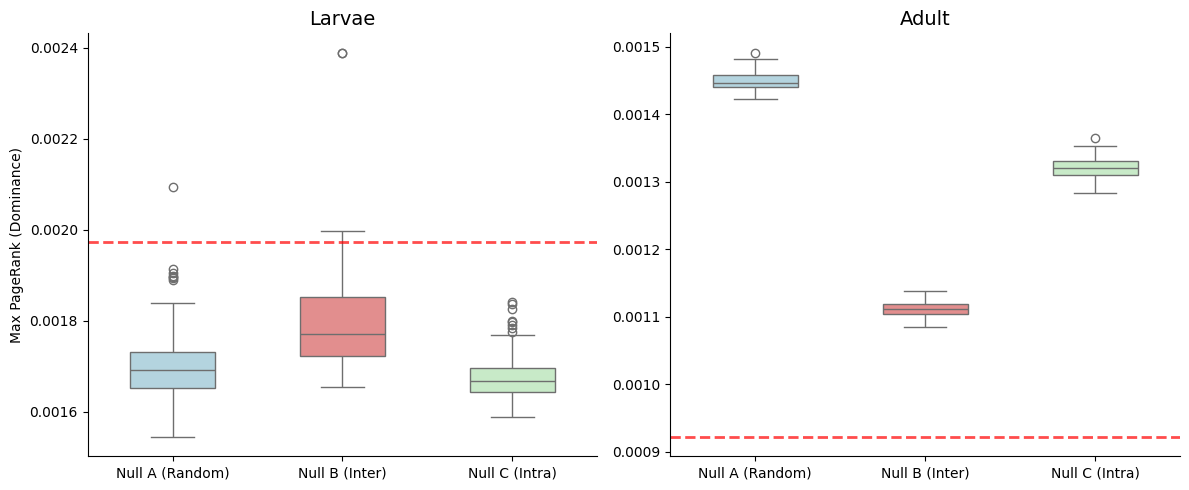

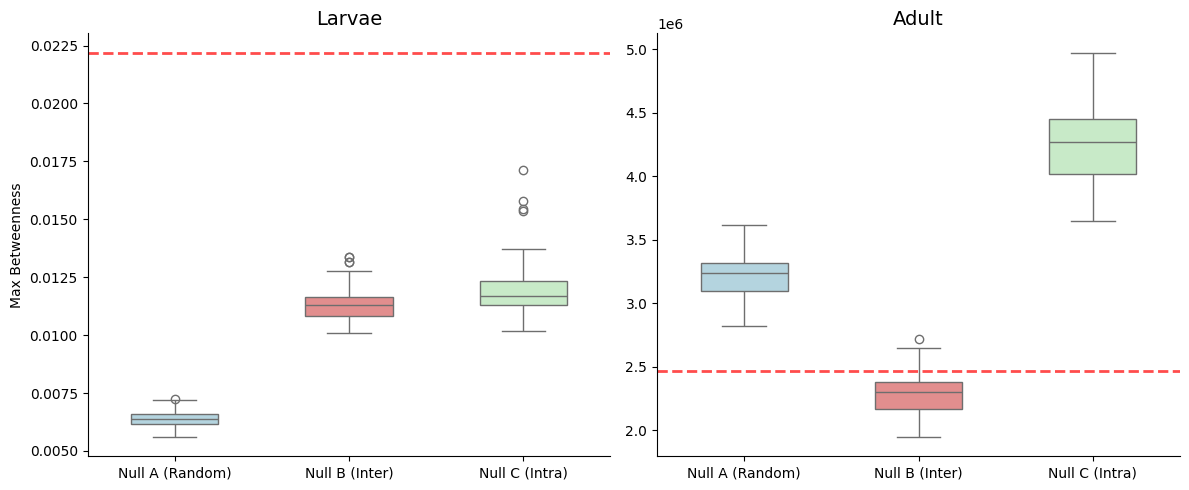

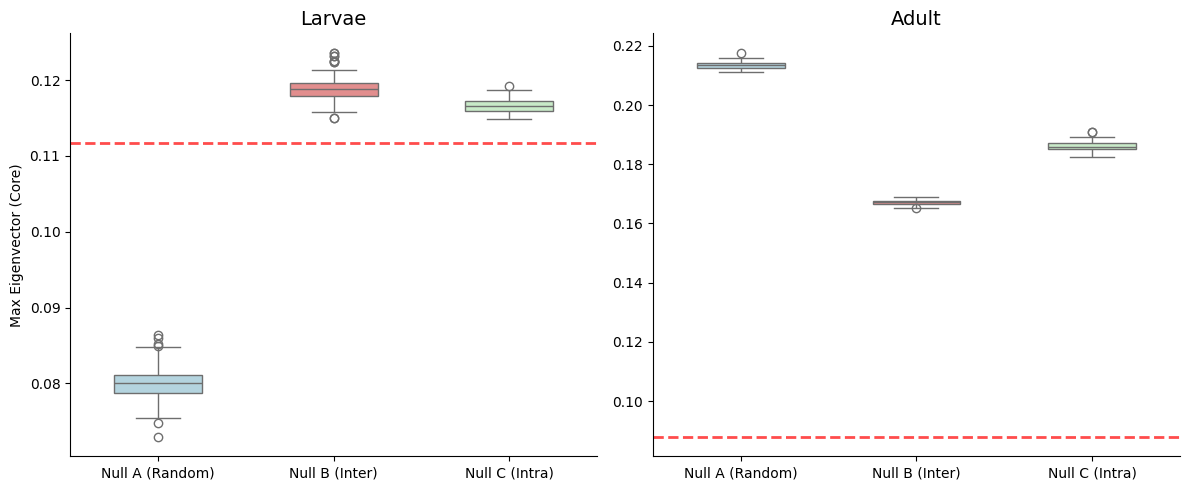

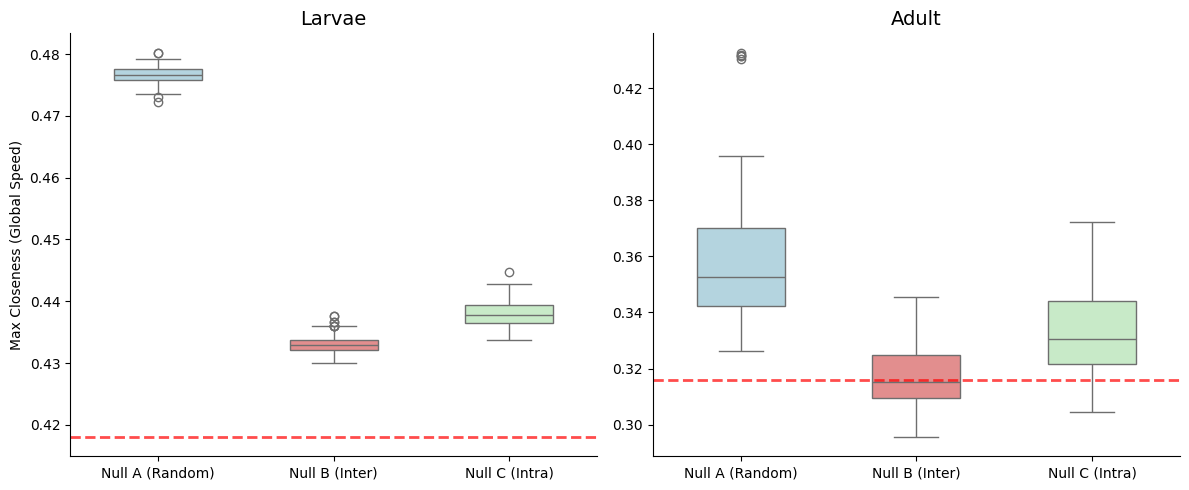

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df1 = pd.read_csv('analysis/results_centrality_adult.csv')
df2 = pd.read_csv('analysis/results_centrality_larvae.csv')

df1['Stage'] = 'Adult'
df2['Stage'] = 'Larva'

df = pd.concat([df1, df2], axis=0)
df_real_adult = pd.read_csv('analysis-original/adult_centrality.csv')
df_real_larvae = pd.read_csv('analysis-original/larvae_centrality.csv')

REAL_VALS = {
    'PageRank_Max':    {'Larvae': df_real_larvae.loc[0, 'PageRank_Max'], 'Adult': df_real_adult.loc[0, 'PageRank_Max']}, 
    'Betweenness_Max': {'Larvae': df_real_larvae.loc[0, 'Betweenness_Max'], 'Adult': df_real_adult.loc[0, 'Betweenness_Max']}, 
    'Eigenvector_Max': {'Larvae': df_real_larvae.loc[0, 'Eigenvector_Max'], 'Adult': df_real_adult.loc[0, 'Eigenvector_Max']}, 
    'Closeness_Max':  {'Larvae': df_real_larvae.loc[0, 'Closeness_Max'], 'Adult': df_real_adult.loc[0, 'Closeness_Max']}  
}

df['Stage'] = df['Network'].apply(lambda x: x.split('_')[0].capitalize())
df['Null_ID'] = df['Network'].apply(lambda x: x.split('_')[1])
null_map = {
    'null0': 'Null A (Random)', 
    'null1': 'Null B (Inter)',  
    'null2': 'Null C (Intra)',  
}
df['Null_Type'] = df['Null_ID'].map(null_map)

metrics = [
    ('PageRank_Max',    'PageRank Centrality (Max)',    'Max PageRank (Dominance)'),
    ('Betweenness_Max', 'Betweenness Centrality (Max)', 'Max Betweenness'),
    ('Eigenvector_Max', 'Eigenvector Centrality (Max)', 'Max Eigenvector (Core)'),
    ('Closeness_Max',  'Closeness Centrality (Max)',  'Max Closeness (Global Speed)')
]

colors = ["#add8e6", "#f08080", "#c2f0c2"]

for col, title, ylabel in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    
    stages = ['Larvae', 'Adult']
    
    for i, stage in enumerate(stages):
        subset = df[df['Stage'] == stage]

        sns.boxplot(x='Null_Type', y=col, data=subset, ax=axes[i], palette=colors, width=0.5)
        
        if col in REAL_VALS and stage in REAL_VALS[col]:
            real_val = REAL_VALS[col][stage]
            axes[i].axhline(real_val, color='red', linestyle='--', linewidth=2, alpha=0.7)

        axes[i].set_title(f"{stage}", fontsize=14)
        axes[i].set_xlabel("")
        axes[i].set_ylabel(ylabel if i==0 else "")
        sns.despine(ax=axes[i])
        
    plt.tight_layout()
    plt.show()

# Rich Clubs

In [103]:
def load_phi_series(filepath):
    try:
        df = pd.read_csv(filepath)
        df.columns = [c.lower() for c in df.columns] 
        df = df.set_index('k')
        return df['phi']
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

def get_normalized_curve(config):

    real_phi = load_phi_series(config['Real_File'])
    null_files = glob.glob(os.path.join(config['Null_Folder'], "*null0*.csv"))

    null_list = []
    for f in null_files:
        s = load_phi_series(f)
        if s is not None:
            null_list.append(s)
            
    null_df = pd.concat(null_list, axis=1)
    
    mean_null_phi = null_df.mean(axis=1)
    std_null_phi = null_df.std(axis=1)
    
    common_k = real_phi.index.intersection(mean_null_phi.index)
    common_k = common_k.sort_values()
    
    aligned_real = real_phi.loc[common_k]
    aligned_mean = mean_null_phi.loc[common_k]
    aligned_std = std_null_phi.loc[common_k]

    norm_phi = aligned_real / aligned_mean
    norm_std = aligned_std / aligned_mean
    
    return common_k, norm_phi, norm_std



In [104]:
DATA_CONFIG = {
    'Larvae': {
        'Real_File': 'analysis-original/rich_club/larvae_ws_rich_club_curve.csv',
        'Null_Folder': 'analysis/rich_club_larvae/',
        'Color': '#e74c3c'
    },
    'Adult': {
        'Real_File': 'analysis-original/rich_club/adult_ws_rich_club_curve.csv',
        'Null_Folder': 'analysis/rich_club_adult/',
        'Color': '#2c3e50'
    }
}

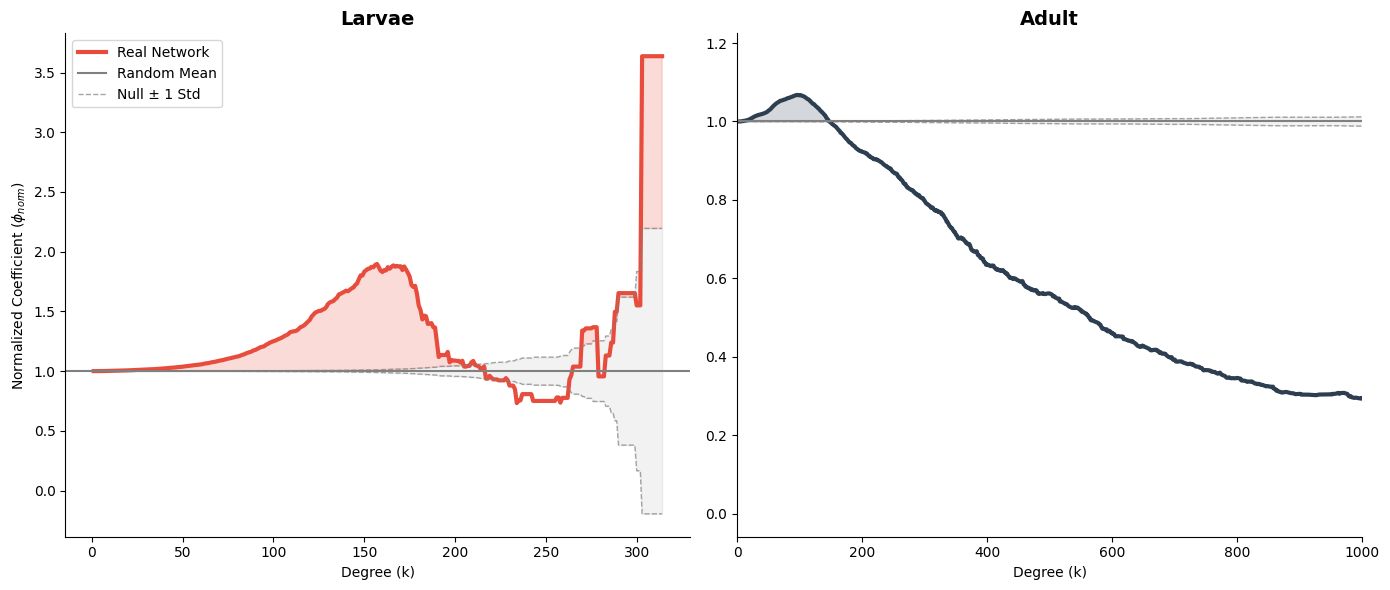

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import glob


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (stage, config) in enumerate(DATA_CONFIG.items()):
    ax = axes[i]
    
    k_vals, norm_vals, norm_std = get_normalized_curve(config)
    
    if k_vals is not None:
        ax.plot(k_vals, norm_vals, color=config['Color'], linewidth=3, label='Real Network')
        ax.axhline(1.0, color='grey', linestyle='-', linewidth=1.5, label='Random Mean')
        
        upper_bound = 1.0 + norm_std
        lower_bound = 1.0 - norm_std
        
        ax.plot(k_vals, upper_bound, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='Null ± 1 Std')
        ax.plot(k_vals, lower_bound, color='grey', linestyle='--', linewidth=1, alpha=0.7)
        
        ax.fill_between(k_vals, lower_bound, upper_bound, color='grey', alpha=0.1)

        ax.fill_between(k_vals, upper_bound, norm_vals, where=(norm_vals > upper_bound), 
                        color=config['Color'], alpha=0.2, interpolate=True)
        
        ax.set_title(f"{stage}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Degree (k)")
        ax.set_ylabel("Normalized Coefficient ($ \phi_{norm} $)" if i==0 else "")
        
        if i == 0:
            ax.legend(loc='upper left')
            
        if stage == 'Adult':
             ax.set_xlim(0, 1000) 
        
        sns.despine(ax=ax)


plt.tight_layout()
plt.show()

In [106]:
DATA_CONFIG = {
    'Larvae': {
        'Real_File': 'analysis-original/rich_club/larvae_ws_rich_club_curve.csv',
        'Null_Folder': 'analysis/rich_club_larvae/',
        'Color': '#e74c3c'
    },
    'Adult': {
        'Real_File': 'analysis-original/rich_club/adult_ws_rich_club_curve.csv',
        'Null_Folder': 'analysis/rich_club_adult/',
        'Color': '#2c3e50'
    }
}

results = []

for connectome in ['Larvae', 'Adult']:
    
    deg_sec = np.load(f"analysis-original/{connectome.lower()}_deg.npy")
    
    k_vals, norm_vals, norm_std = get_normalized_curve(DATA_CONFIG[connectome])
        
    for std in range(6):
    
        # calculate the rich club
        
        bound = 1 + std * norm_std
    
        rich_club_indices = np.where(norm_vals > bound)[0]
        
        # find out the biggest rich club
        
        diffs = np.diff(rich_club_indices)
        
        big_diffs = np.where(diffs > 1)[0]
        big_diffs = np.insert(big_diffs, 0, -1)
        big_diffs = np.append(big_diffs, len(rich_club_indices) - 1)
        
        starts = rich_club_indices[big_diffs[:-1] + 1]
        ends = rich_club_indices[big_diffs[1:]]
        
        rich_club_sizes = ends - starts + 1
        
        biggest_rich_club_size = rich_club_sizes.max()
        
        max_idx = rich_club_sizes.argmax()
        
        rich_club_range = (starts[max_idx], ends[max_idx])
    
        # find out how many neurons are involved
    
        nodes_in_rich_club = ((deg_sec >= rich_club_range[0]) & (deg_sec <= rich_club_range[1])).sum()

        nodes_in_percent = nodes_in_rich_club / deg_sec.shape[1]
    
        results.append((connectome, std, biggest_rich_club_size, rich_club_range, nodes_in_rich_club, nodes_in_percent))


In [107]:
import pandas as pd

df = pd.DataFrame(results, columns=["Connectome", "σ", "rich_club_size", "rich_club_range", "neurons_involved", "percent_involved"])

In [108]:
df

,Connectome,σ,rich_club_size,rich_club_range,neurons_involved,percent_involved
0,Larvae,0,216,"(0, 215)",2906,0.984417
1,Larvae,1,204,"(0, 203)",2890,0.978997
2,Larvae,2,196,"(0, 195)",2879,0.975271
3,Larvae,3,196,"(0, 195)",2879,0.975271
4,Larvae,4,190,"(0, 189)",2866,0.970867
5,Larvae,5,190,"(0, 189)",2866,0.970867
6,Adult,0,147,"(0, 146)",130113,0.938875
7,Adult,1,146,"(0, 145)",130032,0.938290
8,Adult,2,146,"(0, 145)",130032,0.938290
9,Adult,3,146,"(0, 145)",130032,0.938290


In [109]:
data_df = df[df['σ'] < 4]
rows = data_df[["Connectome", "σ", "rich_club_range", "percent_involved"]].values
latex = ""
for row in rows:
    row_list = [str(itm) for itm in row]
    row_list[-1] = f"{float(row_list[-1]):.5f}"
    latex += " & ".join(row_list)
    latex += " \\\\\n"


In [110]:
print(latex)

Larvae & 0 & (0, 215) & 0.98442 \\
Larvae & 1 & (0, 203) & 0.97900 \\
Larvae & 2 & (0, 195) & 0.97527 \\
Larvae & 3 & (0, 195) & 0.97527 \\
Adult & 0 & (0, 146) & 0.93887 \\
Adult & 1 & (0, 145) & 0.93829 \\
Adult & 2 & (0, 145) & 0.93829 \\
Adult & 3 & (0, 145) & 0.93829 \\

